In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('mode.chained_assignment', None)
warnings.simplefilter("ignore", category=RuntimeWarning)

import random
import os
from juno_classes import *
from tqdm.notebook import tqdm
import time


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 100  # in MB
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt

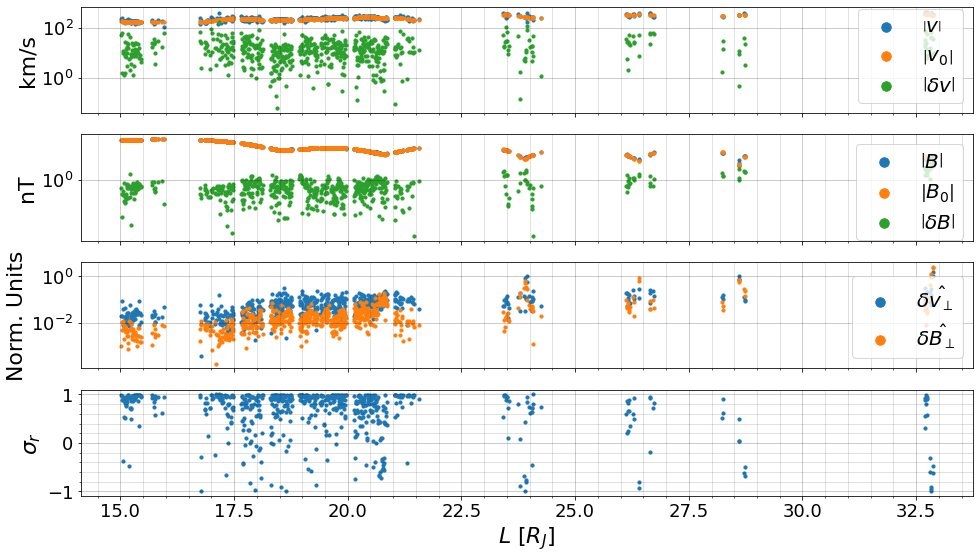

In [2]:
fig,ax = plt.subplots(4,1, figsize=(16,9),sharex = 'all')
filename = 'combined_fits_dfs_20.pkl'
picklefile = open(filename,'rb')
combined_fits_dfs = pickle.load(picklefile)
start_index = 0
end_index = -1
size = 10


combined_fits_dfs_lim = combined_fits_dfs.iloc[np.where( (combined_fits_dfs['R_cyl_jss'] < 35 ) & (combined_fits_dfs['R_cyl_jss'] > 15)    )]
combined_fits_dfs_lim = combined_fits_dfs_lim.dropna()

ax[0].scatter(combined_fits_dfs_lim.iloc[start_index:end_index]['R_cyl_jss'], combined_fits_dfs_lim.iloc[start_index:end_index]['|U|'],s=size,label = r'$\left|v\right|$')
ax[0].scatter(combined_fits_dfs_lim.iloc[start_index:end_index]['R_cyl_jss'], combined_fits_dfs_lim.iloc[start_index:end_index]['|MEAN_U|'],s=size, label = r'$\left|v_0\right|$')
ax[0].scatter(combined_fits_dfs_lim.iloc[start_index:end_index]['R_cyl_jss'], np.abs(combined_fits_dfs_lim.iloc[start_index:end_index]['|U|']-combined_fits_dfs_lim.iloc[start_index:end_index]['|MEAN_U|']),s=size,label = r'$\left|{\delta}v\right|$')
ax[0].set_yscale('log')

ax[0].legend(loc = 'lower right',fontsize = 20,markerscale=3)

ax[1].scatter(combined_fits_dfs_lim.iloc[start_index:end_index]['R_cyl_jss'], combined_fits_dfs_lim.iloc[start_index:end_index]['raw_magnitude'],s=size,label = r'$\left|B\right|$')
ax[1].scatter(combined_fits_dfs_lim.iloc[start_index:end_index]['R_cyl_jss'], combined_fits_dfs_lim.iloc[start_index:end_index]['mean_magnitude']*10**9,s=size, label = r'$\left|B_0\right|$')
ax[1].scatter(combined_fits_dfs_lim.iloc[start_index:end_index]['R_cyl_jss'], np.abs(combined_fits_dfs_lim.iloc[start_index:end_index]['raw_magnitude']-combined_fits_dfs_lim.iloc[start_index:end_index]['mean_magnitude']*10**9),s=size, label = r'$\left|{\delta}B\right|$')

ax[1].legend(fontsize=20,markerscale=3)
ax[1].set_yscale('log')

ax[3].scatter(combined_fits_dfs_lim.iloc[start_index:end_index]['R_cyl_jss'], combined_fits_dfs_lim.iloc[start_index:end_index]['norm_residual_energy'],s = size)



ax[2].scatter(combined_fits_dfs_lim.dropna().iloc[start_index:end_index]['R_cyl_jss'], combined_fits_dfs_lim.dropna().iloc[start_index:end_index]['|delta_vperp_norm|'],label = r'$\hat{\delta{v_{\perp}}}$',s=size)

ax[2].scatter(combined_fits_dfs_lim.dropna().iloc[start_index:end_index]['R_cyl_jss'], combined_fits_dfs_lim.dropna().iloc[start_index:end_index]['|delta_Bperp_norm|'],s=size,label =  r'$\hat{\delta{B_{\perp}}}$')

ax[2].set_yscale('log')

ax[2].legend(fontsize = 20,loc ='lower right',markerscale=3)


labelsize = 22

ax[0].set_ylabel(r"km/s",fontsize = labelsize)
ax[1].set_ylabel(r"nT",fontsize = labelsize)
ax[2].set_ylabel(r"Norm. Units",fontsize = labelsize)
ax[3].set_ylabel(r"$\sigma_r$",fontsize = labelsize)
ax[3].set_xlabel(r'$L$ [$R_J$]',fontsize = labelsize)

label_size_set2 = 18
ax[0].tick_params(axis='both', labelsize=label_size_set2)
ax[1].tick_params(axis='both', labelsize=label_size_set2)
ax[2].tick_params(axis='both', labelsize=label_size_set2)
ax[3].tick_params(axis='both', labelsize=label_size_set2)

for i in range(len(ax)):
    ax[i].minorticks_on()

    ax[i].grid(which='major', linestyle='-', color='black', alpha=0.25)
    ax[i].grid(which='minor', linestyle='-', color='black', alpha=0.15)
    


fig.set_facecolor('white')
plt.show()